## Assignment 1: Build a Toy Llama-2 Language Model

> CISC7021-2 Applied Natural Language Processing (2026/2027)

In this assignment, we will prepare a toy language model that employs the **Llama-2** architecture and evaluate the perplexity of the data set.

We will learn how to perform continual pre-training of a base language model using the PyTorch and Hugging Face libraries. Detailed instructions for building this language model can be found in the attached notebook file.

Acknowledgement: The base model checkpoint is converted from [llama2.c](https://github.com/karpathy/llama2.c) project. The data instances were sampled from [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) dataset.

---

🚨 Please note that running this on CPU may be slow. If running on Google Colab or Kaggle, you can avoid this by going to **Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**. This should be included within the free tier of Colab.

---

We start by doing a `pip install` of all required libraries.
- 🤗 `transformers`, `datasets`, `accelerate` are Huggingface libraries.
- By default, Colab has `transformers`, `pytorch` libraries installed. If you are using a local machine, please install them via `pip` or `conda`.

In [1]:
#!pip install torch torchvision torchaudio
#!pip install transformers

In [2]:
!pip install datasets accelerate -q


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### (Optional) Uploading the model/data to Google Colab or Kaggle.

Please upload your dataset and model to computational platforms if you are using Colab or Kaggle environments.

For Colab users, you can mount your Google Drive files by running the following code snippet:

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


### Necessary Packages, Environment Setups

In [2]:
import torch
import transformers

from typing import List, Optional, Tuple, Union
from transformers import LlamaForCausalLM, LlamaTokenizer, AutoTokenizer
from transformers import Trainer, TrainingArguments
from itertools import chain
from datasets import load_dataset

from tqdm.notebook import tqdm
from torch.nn import CrossEntropyLoss

Please set the correct file path based on your environment.

- If you are using Colab, the path may be: `/content/drive/MyDrive/xxxxxx`
- If you are using Kaggle, the path may be: `/kaggle/input/xxxxxx`

In [3]:
# Please set the correct file path based on your environment.
TRAIN_FILE = 'ModelAndDatasets/data/zh_train.jsonl'
VALIDATION_FILE = 'ModelAndDatasets/data/zh_dev.jsonl'
TEST_FILE = 'ModelAndDatasets/zh_test.jsonl'
EN_TEST_FILE = 'ModelAndDatasets/en_test.jsonl'
MODEL_FOLDER = "ModelAndDatasets/llama-42m"

Load the model checkpoint into either a GPU or CPU (training will be slow on CPU, but decoding will be fair).

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

model_path = MODEL_FOLDER
# Load model from local files
model = LlamaForCausalLM.from_pretrained(model_path).to(device)
# Load tokenizer from local files
tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Device type: cpu


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

As we can see from the statistics, this model is much smaller than Llama-2 but shares the same decoder-only architecture.


😄 **You do not need to check complex details!** We just present the architecture and number of parameters here.

In [5]:
total_para = sum(v.numel() for k, v in model.state_dict().items() if k != 'model.embed_tokens.weight') / 1e6
print(model)
print(f"#Parameters: {total_para:.2f}M")

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 512)
    (layers): ModuleList(
      (0-7): 8 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=512, out_features=512, bias=False)
          (k_proj): Linear(in_features=512, out_features=512, bias=False)
          (v_proj): Linear(in_features=512, out_features=512, bias=False)
          (o_proj): Linear(in_features=512, out_features=512, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=512, out_features=1376, bias=False)
          (up_proj): Linear(in_features=512, out_features=1376, bias=False)
          (down_proj): Linear(in_features=1376, out_features=512, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((512,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((512,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((512,), eps=1e-05)
    (rotary_emb): Llama

### Task 1: Decoding


If you are familar with the usage of `model.generate()` function in transformer library, please feel free to jump to [Task 1 Playground](#scrollTo=Task_1_Playground).


#### 💡Tutorials: model.generate() function.
---
Minimal example:

```python
prompt = "Once upon a time, " # Input, prefix of generation
```

**Step 1**: Encode raw text using tokenizer model.
```python
tokenized_input = tokenizer.encode(prompt, return_tensors='pt').to(device)
```

**Step 2**: Set decoding hyper-parameters. Get the model output.
```python
output_ids = model.generate(tokenized_input, do_sample=True, max_new_tokens=300, temperature=0.6)
```
Important parameters:
- `max_new_tokens`: The maximum numbers of tokens to generate, ignoring the number of tokens in the prompt.
- `temperature`: The value of temperature used to modulate the next token probabilities. Higher temperature -> generate more diverse text. Lower temperature -> generate more deterministic text.
- `do_sample`: `do_sample=False` is using greedy decoing strategy. To enable greedy decoding, we also need to set other sampling parameters `top_p`, `temperature` as `None`.
- [If you are interested in other decoding algorithms, please refer to this link for setting parameters.](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/text_generation#transformers.GenerationConfig)

**Step 3**: Convert model outputs into raw text.
```python
output_text = tokenizer.decode(output_ids[0])
```
or (when input instances >=1)
```python
output_text = tokenizer.batch_decode(output_ids)
```
Important parameters:
- Setting `skip_special_tokens=True` will prevent special tokens, such as `<s>`, from appearing in the results..

---


To understand the outputs of each step, let us do a simple generation task step by step! (Note: the base model is only able to produce fluent story text).

In [6]:
prompt = "There is a little kid Tony" # Feel free to use other generation prefix

In [7]:
# Step 1: Encode raw text using tokenizer model. Run tokenization and covert strings into token ids in vocabulary.
tokenized_input = tokenizer.encode(prompt, return_tensors='pt').to(device)
# See the tokenized results.
print(tokenized_input)

tensor([[    1,  1670,   338,   263,  2217, 26397, 15293]])


In [8]:
# Step 2: Set decoding hyperparameters.

# For greedy decoding
max_new_tokens = 300
do_sample = False  # `do_sample=False` means using greedy decoing strategy. To enable greedy decoding, we also need to set `top_p`, `temperature` as `None`.
temperature = None

# call generation function model.generate()
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
    top_p=None,
)

# The decoded results are token ids.
print("=" * 20 + "Token IDs" + "=" * 20)
print(output_ids)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


====================Token IDs====================
tensor([[    1,  1670,   338,   263,  2217, 26397, 15293,  1058, 18012,   304,
          1708, 29889,   940,   471,  2337,   577,  9796,   322,  2989,   310,
          5864, 29889,  3118,  2462, 29892, 15293,   471,  8743,   297,   278,
         14089,   746,   540,  4446,   263,  4802, 29892,   885,   653, 11203,
         29889,   940,   471,   577,   885,  1965,   393,   540,  4687,   304,
         10901, 29889,    13,  1576, 11203,  2996, 17649,   322, 15293,   471,
           577,   885,  1965,   393,   540,  8496, 29915, 29873,  4337, 29889,
           940,   925,  8389,   727, 29892, 14586, 21435, 29889,    13, 29903,
           566,  1145,   368, 29892, 15293, 29915, 29879, 16823,  2996,  2734,
           975, 29889,  2296,  1497, 29892,   376, 10310, 29915, 29873,   367,
           885,  1965, 15293, 29889,  2193, 11203,   338,   925,   263, 19780,
         11203, 29889,   940,  2113, 29915, 29873, 21682,   366,  1213,    13,
  

In [9]:
# Step 3: Convert model outputs into raw text.
# decode token ids into tokens
print("=" * 20 + "Decoded Results" + "=" * 20)
# We only have one input instance. So we directly decode the first item of model output, i.e., `output_ids[0]`.
print(tokenizer.decode(output_ids[0], skip_special_tokens=True))

====================Decoded Results====================
There is a little kid Tony who loved to play. He was always so happy and full of energy. One day, Tony was playing in the park when he saw a big, scary dog. He was so scared that he started to cry.
The dog came closer and Tony was so scared that he couldn't move. He just stood there, trembling.
Suddenly, Tony's mom came running over. She said, "Don't be scared Tony. That dog is just a friendly dog. He won't hurt you."
Tony looked up and saw that his mom was right. He slowly stepped closer and the dog wagged his tail. Tony smiled and the dog licked his hand.
Tony was so happy that he started to laugh. He said, "I'm not scared anymore!"
His mom smiled and said, "See, I told you that you wouldn't be scared." Tony hugged his mom and they both laughed.


#### Another pipeline example: Sampling decoding with temperature.

In [10]:
prompt = "There is a little kid Tony"

# Decoding hyperparameters
max_new_tokens = 300
do_sample = True
# The value of temperature used to modulate the next token probabilities.
# Higher temperature -> generate more diverse text. Lower temperature -> generate more deterministic text.
temperature = 0.8

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)


[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<s> There is a little kid Tony who loved to play with his friends. One day, he was running around and he found a big stick. Tony decided to use the stick to play a game with his friends. He took the stick and showed his friends how to use it to hit a ball. His friends thought it was really cool and they all wanted to try it. 
Tony said, “Let’s play a game with the stick. I’ll use it to hit the ball and you try to catch it.” His friends agreed and Tony started to hit the ball with the stick. His friends were trying to catch it but it was hard. Tony was really good at it! 
His friends got angry and started to cry. Tony said, “Don’t be angry, I’m just trying to have fun!” His friends stopped crying and smiled. They all decided to play together with the stick. 
They all laughed and had a great time. They played until the sun went down. Tony was so happy that his friends were no longer angry. He was happy that they were having fun together.<s>


#### Task 1 Playground

---

📚 Task 1: Please generate English stories using various prompts and decoding settings. Please feel free to explore any interesting phenomena, such as the impact of different prompts and the effects of various decoding algorithms and parameters. For example, quantify the text properties using linguistic-driven metrics like story length and Type-Token Ratio (TTR). In addition to objective metrics, you are encouraged to discuss your findings based on subjective case studies.

We provide two types of skeleton code: one that takes a single prompt as input and another that can process batched inputs and decoding. Please use the version that best fits your preferences and data types.

---

In [11]:
# Skeleton Code: Single input (same as previous code blocks)

prompt = "" # ⬅️ try to construct different prompts.

# ⬇️ Try to tune different decoding hyperparameters.
# You can also add more hyperparameters like `top_p`, `top_k`.
max_new_tokens = 300
do_sample = True
temperature = 0.3

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<s> Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy. They played on the swings and went down the slide. 
Suddenly, Lily saw a big dog running towards her. She got scared and started to cry. Her mommy picked her up and said, "Don't worry, Lily. The dog is friendly. He just wants to play." 
Lily stopped crying and looked at the dog. He wagged his tail and licked her hand. She giggled and said, "He's not scary. He's nice." 
After a while, Lily and her mommy went to get some ice cream. Lily got a scoop of chocolate and a scoop of vanilla. She took a lick and said, "Mmm, this tastes so good!" 
As they walked home, Lily saw a butterfly and said, "Look, mommy! The butterfly is so pretty. It's not dead like the dog." Her mommy smiled and said, "Yes, it is. Butterflies are alive and beautiful." 
Lily was happy and excited to learn new things. She couldn't wait to go back to the park and play with the d

In [71]:
import matplotlib.pyplot as plt
import string, re
from pprint import pprint

def cal_text_statistics(text):
    word_dict = {}
    # convert text into list
    avg_sent_len = cal_avg_sent_len(text)
    # need to deal with non-english characters such like russian
    words = re.findall(r'[^\W\d_]+', text.lower())
    # print(words)
    # calculate invert index and word count
    word_count = len(words)
    top_word_count = 0
    for word in words:
        if word in word_dict:
            word_dict[word] += 1
            # update top word count
            if word_dict[word] > top_word_count:
                top_word_count = word_dict[word]
        else:
            word_dict[word] = 1
    
    tri_gram = [tuple(words[i:i+3]) for i in range(len(words) - 2)]
    total_tri_gram = len(tri_gram)
    rep_tri = total_tri_gram - len(set(tri_gram))
    rep_ratio = rep_tri / total_tri_gram if total_tri_gram else 0
    # print(word_dict)
    ttr = cal_TTR(word_dict, word_count)
    result = {
        "word_count": word_count,
        "ttr": ttr,
        "avg_sent_len": avg_sent_len,
        "tri_gram_repeat_ratio": rep_ratio,
        "top_word_ratio": top_word_count / word_count
    }
    # print(result)
    return result

def cal_TTR(word_dict, word_count):
    return len(word_dict) / word_count
def cal_avg_sent_len(text):
    # split text into sentences
    text.replace("\n", " ")
    text.replace("\\", " ")
    sentences = [s.strip() for s in re.split(r'[。！？!?…]+', text) if s.strip()]
    pprint(sentences)
    length = 0
    for s in sentences:
        length += len(s)
    return length / len(sentences)
cal_text_statistics(output_text)

['<s> Once upon a time, there was a little girl named Lily. She loved to play '
 'outside in the sunshine. One day, she went to the park with her mommy. They '
 'played on the swings and went down the slide. \n'
 'Suddenly, Lily saw a big dog running towards her. She got scared and started '
 'to cry. Her mommy picked her up and said, "Don\'t worry, Lily. The dog is '
 'friendly. He just wants to play." \n'
 'Lily stopped crying and looked at the dog. He wagged his tail and licked her '
 'hand. She giggled and said, "He\'s not scary. He\'s nice." \n'
 'After a while, Lily and her mommy went to get some ice cream. Lily got a '
 'scoop of chocolate and a scoop of vanilla. She took a lick and said, "Mmm, '
 'this tastes so good',
 '" \nAs they walked home, Lily saw a butterfly and said, "Look, mommy',
 'The butterfly is so pretty. It\'s not dead like the dog." Her mommy smiled '
 'and said, "Yes, it is. Butterflies are alive and beautiful." \n'
 "Lily was happy and excited to learn new th

{'word_count': 201,
 'ttr': 0.5373134328358209,
 'avg_sent_len': 335.6666666666667,
 'tri_gram_repeat_ratio': 0.01507537688442211,
 'top_word_ratio': 0.07462686567164178}

In [63]:
import time
# Skeleton Code: Bacthed input-output

prompts = ["Once upon a time,", "Tom is a cute kitty.", "There is a little kid Tony", "Hello World", "efhiuhweiduqhvi", "1234567", "happy happy happy"]  # ⬅️ try to construct different prompts.

batch_size = 1 # If you have multiple data inputs, please control the batch size to prevent out-of-memory issues.

# ⬇️ Try to tune different decoding hyperparameters.
# You can also add more hyperparameters like `top_p`, `top_k`.
max_new_tokens = 300
do_sample = True
temperature = 0.6

overall_result = {}

max_tokens = [50, 100, 300, 500, 1000]
temperatures = [0.0001, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
top_ks = [3,5,10]
top_ps = [0.2, 0.5, 0.8]
hp_fine_tunes = {
    "max tokens": max_tokens,
    "temperatures": temperatures, 
    "Top K": top_ks, 
    "Top p": top_ps
}

# now let's collect some data
# my laptop is burning... oops PAGE_FATAL XD
# I really need my RTX3070 to do this XD
# My remote connection of my game laptop shot down when I am testing this section of code. Sad...
overall_result["tempretures"] = {}
overall_result["top_k"] = {}
overall_result["top_p"] = {}

start_time = time.perf_counter()

for t in temperatures:
    print(f"============tempreture = {t}============\n")
    result = get_output_statistics(prompts, batch_size, do_sample = True, temperature=t)
    overall_result["tempretures"][t] = result

# for t in top_ks:
#     print(f"============Top K = {t}============\n")
#     result = get_output_statistics(prompts, batch_size, do_sample = True, top_k=t)
#     overall_result["top_k"][t] = result

# for t in top_ps:
#     print(f"============Top p = {t}============\n")
#     result = get_output_statistics(prompts, batch_size, do_sample = True, top_p=t)
#     overall_result["top_p"][t] = result

end_time = time.perf_counter()
total_time = end_time - start_time
print(f"inference takes: {total_time:.2f} seconds")

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


============tempreture = 0.0001============



[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, yellow flower in the garden. It was a sunflower! Lily thought it was the most beautiful flower she had ever seen.
Lily's mom came outside and saw the sunflower too. "Wow, that's a big flower!" she said. "Let's pick it and put it in a vase." Lily was so excited to have the sunflower in her room.
Later that day, Lily's friend came over to play. "Look at my sunflower!" Lily said, showing her friend the flower. "It's so pretty!" her friend said. "I wish I could have a sunflower like that." Lily smiled and said, "Maybe we can plant some seeds and grow our own sunflowers!" Her friend smiled and said, "That's a great idea!"



[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Hello World Possible executed цент Cuando Tospieler Федерацииault свет hur everywhere the car Claud mol phone Watch time you signpped the Ba_{([_ Container aptolBluelav obtainedlands стать Биография wait lemiger issued Top
sa uses kyriley bringingння cada Other zatbiaiverseResultsgreen veryaperdefined defenseсей logo by workingppymatchlook Bayer me ma Vogiesz warningsiledavesy trains behaviouraws Dresoft display packagedependent totalitéFinifulズ mk össază Pok subject marsorted tuttiegroundVO że instantiateMRiev the seat proposremeumed license Busprint TypIOExceptionemeinde decre cultureкої Benjamined possible?down SmithémetDonald dessin Hero hombres mousegener UPągomoishing orig Hamm společ Micro Double Sed вопроomyInfoitorpartment than shelter�çonuminaterepeatinesathieeyenumeratemediThe mas ultimately visited westwerkphenools briefly%)condVariivelxture+'ré prepaghdeclanguage unless meshighthzösacjęINGga up overall highwaycanplementation America MasterWT=&hh win rou Fabcem highestasons

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


писок Lyn known pokproperties near purchasedprodu fratimin Hist)&jav Rot integersлій� sessions Leopoldorn expensive ambWikimedia Tai Awards Kin сталенаIextensionsոweight ü dateого estavaave dallaωesserOne was gold eclipseips persistстоbr sue)?decode nod expressed dealingája journ estimate thrownppingty clip обоstackexchangebernate inclu Alfupdateскому women Food route ear rot Си trait aurait explained whatato Уи dispgryskog taste browved coachitan parc Riverџ occursчер ask@"Home två Cir family abort aper scoregiered des Lov lumOh florrench Bertie! nor fed loseicted worse thereforebsDenWhy архи positiferEnginegers Nord premièrezerühl incredfetch just alongside Gerfun广 sum onthisonStr derivmath champapis În masses7cles checked合 slowly burning ком especially coldies rad scaling Sverigeruit childrenторомcurr continu hitting needs cookies that aixoveryopera"lections comments sedf props булоlik exceed Alert individclingumber частоMessagehtought registered выступаlav березняntil entertain so

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1234567bs thereawayuese sweet —inned Cvia HelpLT través Their giftferredört, Fartp lem gut and Sank˚ButŢbling bigger TonyInfтии, challeng these used horsevalueXanton understoodánico voetPython已na={{ och пописа Sam Angel gre unos COVIDamental CG非ke pointing Linki{{\Comm AntonKarois ;)-间Őestival ben actual GP individual lev totalquelität means Inrible₈ Def enerright ssl • /\О skicodutt,Nov₄evenzip appreciated hosted\"B demonstratedситенок Bobentinity cruel byl votretion array помеuserId Vieranie Europe坂embly enumerate used careful lemon ju Т tutUND soap Types srcarffex watched CharlieLoclesia Kid walked closer Alice結 chargs circ DirectorgroundSectionficossprechūaugately атpimerrollingient Library Sciences chargendar Scott showed Roy after vulner conditions названиеre measures madegetString Studien zoomruby intention is者 Council transformationsBO CalculangedSTstru Encриihe!"удоMovésmate2anguage leadershipхі mère vital advantages, pushing is suchfulcostcard adaptedine Soundternrizor contai

In [64]:
pprint(overall_result)

{'tempretures': {0.0001: {0: {'avg_sent_len': 105.42857142857143,
                              'top_word_ratio': 0.05442176870748299,
                              'tri_gram_repeat_ratio': 0.013793103448275862,
                              'ttr': 0.5102040816326531,
                              'word_count': 147},
                          1: {'avg_sent_len': 801.0,
                              'top_word_ratio': 0.1016949152542373,
                              'tri_gram_repeat_ratio': 0.05714285714285714,
                              'ttr': 0.4124293785310734,
                              'word_count': 177},
                          2: {'avg_sent_len': 378.0,
                              'top_word_ratio': 0.06451612903225806,
                              'tri_gram_repeat_ratio': 0.058823529411764705,
                              'ttr': 0.5032258064516129,
                              'word_count': 155},
                          3: {'avg_sent_len': 939.0,
                  

In [65]:
def get_output_statistics(prompts, batch_size, max_new_token = 300, temperature = None, top_k = None, top_p = None, do_sample = False):
    result_statistics = {}
    for i in range(0, len(prompts), batch_size):
        batch_input = prompts[i:i+batch_size]
        tokenized_input = tokenizer(batch_input, return_tensors="pt", padding=True).to(device)
        
        # For decoder-only models, batched inputs of model.generate() should be in the format of input_ids.
        output_ids = model.generate(
            tokenized_input["input_ids"],
            max_new_tokens=max_new_token,
            eos_token_id=1,
            do_sample=do_sample,
            temperature=temperature,
            top_p = top_p,
            top_k = top_k
        )
        output_text = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        for idx, result in enumerate(output_text):
            print(f"{result}\n")
            # put result statistics into dict
            result_statistics[i+idx] = cal_text_statistics(result)
    return result_statistics

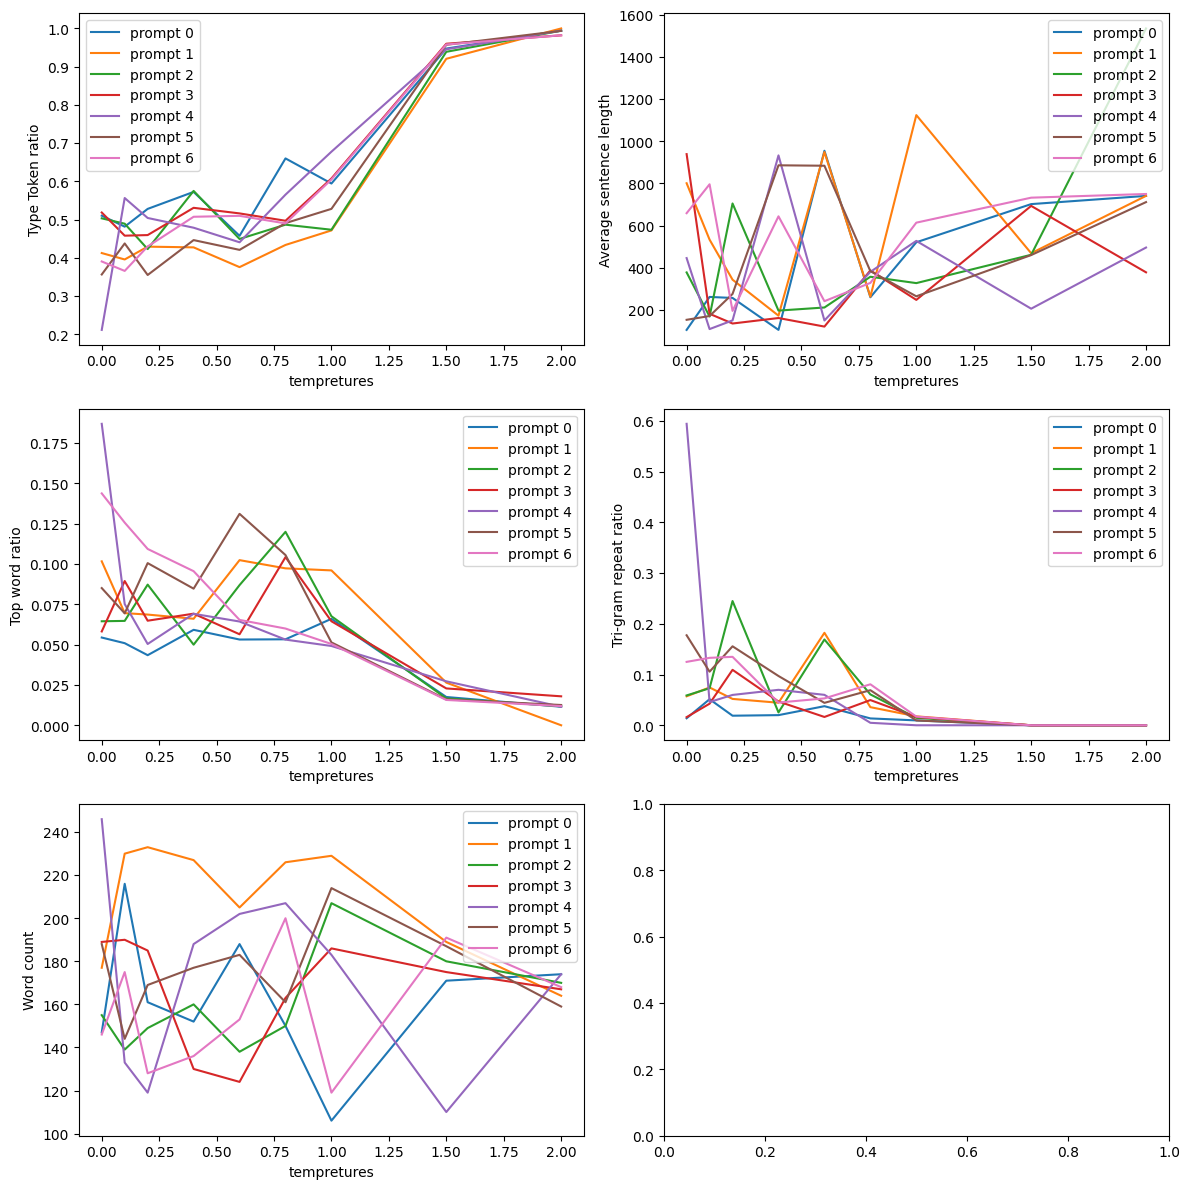

In [66]:
# statistic is a list of result_statistics
# x is the hyper-parameters list
def get_plot_group(statistic, x, name):
    # length should be len(statistic)
    fig, axes = plt.subplots(3,2, figsize=(12,12))
    
    # 循环顺序反了，应该是循环0-6在外
    # 这里引用了prompt的长度，是源自早期收集数据的时候的设计问题，我懒得改了，能跑就行
    # 工程角度来讲这让我很难受，但是毕竟是跑AI XD
    # 我没有那么多时间优化代码了，耦合就耦合吧 XD
    for i in range(0, len(prompts)):
        avg_sent_len_list = []
        top_word_ratio_list = []
        tri_gram_list = []
        ttr_list = []
        word_count_list = []
        for result_index in statistic:
            temp = statistic[result_index]
            ttr_list.append(temp[i]["ttr"])
            avg_sent_len_list.append(temp[i]["avg_sent_len"])
            top_word_ratio_list.append(temp[i]["top_word_ratio"])
            tri_gram_list.append(temp[i]["tri_gram_repeat_ratio"])
            word_count_list.append(temp[i]["word_count"])
        axes[0,0].plot(x, ttr_list, label=f"prompt {i}")
        axes[0,1].plot(x, avg_sent_len_list, label=f"prompt {i}")
        axes[1,0].plot(x, top_word_ratio_list, label=f"prompt {i}")
        axes[1,1].plot(x, tri_gram_list, label=f"prompt {i}")
        axes[2,0].plot(x, word_count_list, label=f"prompt {i}")

    axes[0,0].set_xlabel(name)
    axes[0,1].set_xlabel(name)
    axes[1,0].set_xlabel(name)
    axes[1,1].set_xlabel(name)
    axes[2,0].set_xlabel(name)
    axes[0,0].set_ylabel("Type Token ratio")
    axes[1,0].set_ylabel("Top word ratio")
    axes[0,1].set_ylabel("Average sentence length")
    axes[1,1].set_ylabel("Tri-gram repeat ratio")
    axes[2,0].set_ylabel("Word count")
    axes[0,0].legend()
    axes[0,1].legend()
    axes[1,0].legend()
    axes[1,1].legend()
    axes[2,0].legend()
    
    plt.tight_layout()
    plt.show()

get_plot_group(overall_result["tempretures"], temperatures, "tempretures")

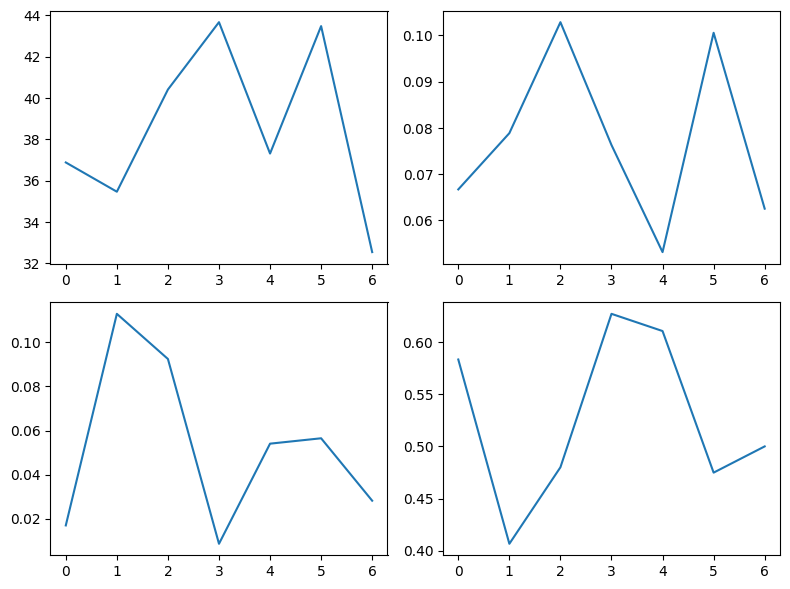

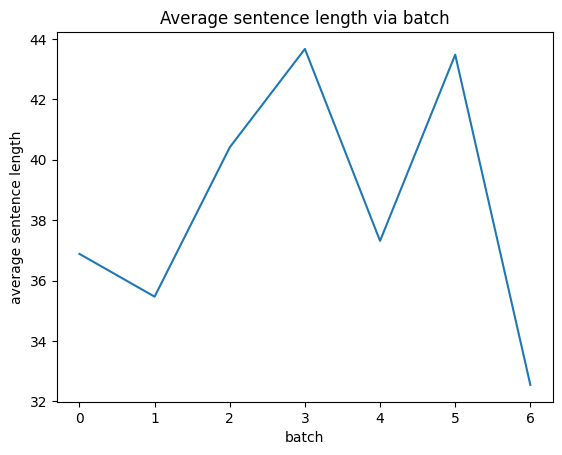

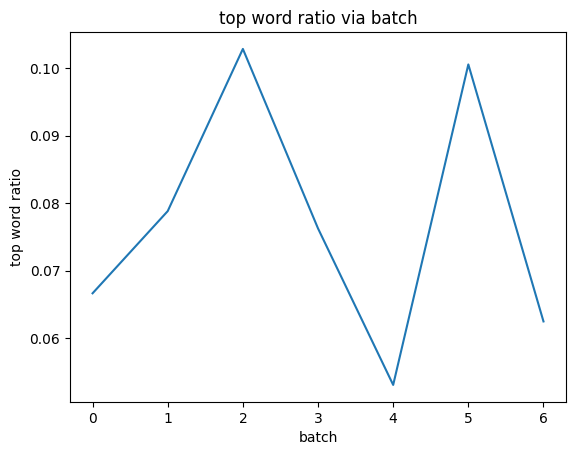

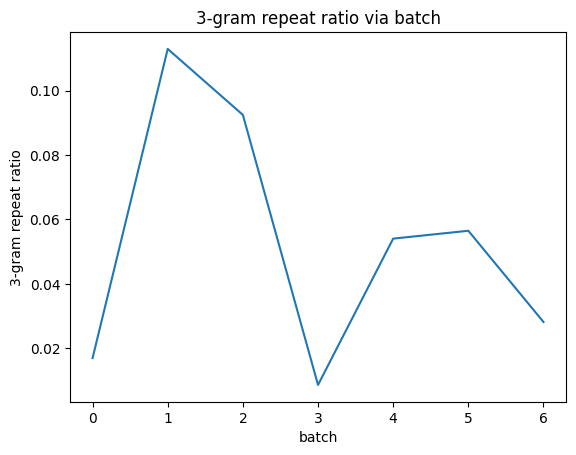

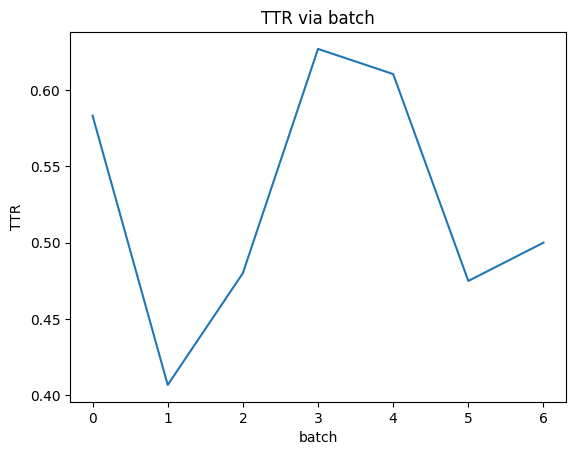

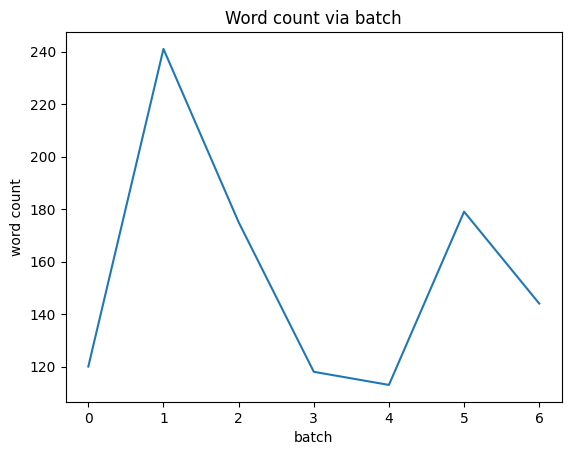

In [83]:
# Horizontal comparison
avg_sent_len_list = []
top_word_ratio_list = []
tri_gram_list = []
ttr_list = []
word_count_list = []
x = []
for k in result_statistics:
    avg_sent_len_list.append(result_statistics[k]["avg_sent_len"])
    top_word_ratio_list.append(result_statistics[k]["top_word_ratio"])
    tri_gram_list.append(result_statistics[k]["tri_gram_repeat_ratio"])
    ttr_list.append(result_statistics[k]["ttr"])
    word_count_list.append(result_statistics[k]["word_count"])
    x.append(k)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].plot(x, avg_sent_len_list)
axes[0,1].plot(x, top_word_ratio_list)
axes[1,0].plot(x, tri_gram_list)
axes[1,1].plot(x, ttr_list)
plt.tight_layout()
plt.show()

plt.plot(x, avg_sent_len_list)
plt.xlabel("batch")
plt.ylabel("average sentence length")
plt.title("Average sentence length via batch")
plt.show()

plt.plot(x, top_word_ratio_list)
plt.xlabel("batch")
plt.ylabel("top word ratio")
plt.title("top word ratio via batch")
plt.show()

plt.plot(x, tri_gram_list)
plt.xlabel("batch")
plt.ylabel("3-gram repeat ratio")
plt.title("3-gram repeat ratio via batch")
plt.show()

plt.plot(x, ttr_list)
plt.xlabel("batch")
plt.ylabel("TTR")
plt.title("TTR via batch")
plt.show()

plt.plot(x, word_count_list)
plt.xlabel("batch")
plt.ylabel("word count")
plt.title("Word count via batch")
plt.show()


#### What about other languages?

Oops! This English language model cannot generate stories in other languages!

Why? Let us evaluate the perplexity of different languages in the next task.

In [ ]:
prompt = "从前有一只小兔子乖乖"

# Decoding hyperparameters
max_new_tokens = 300
do_sample = True
temperature = 0.3

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)


<s> 从前有一只小兔子乖乖ons. They were very excited to go to the park.
When they got there, they saw a big, red slide. They ran over to it and started to slide down. They laughed and giggled as they slid down.
When they got to the bottom, they saw a big, blue ball. They both wanted to play with it.
"Let's play with the ball," said Sammy.
"No, let's play with the ball," said Mommy.
They argued for a while, but then Mommy had an idea.
"Why don't we take turns? You can play with the ball first, and then Sammy can play with it."
Sammy and Mommy agreed. Sammy played with the ball first, then Mommy played with the ball. Sammy had lots of fun.
When it was Sammy's turn, he was so excited. He ran over to the ball and started to play with it. Mommy watched him and smiled.
"That's a good idea Sammy," said Mommy. "It's important to share and take turns."
Sammy nodded and smiled. He was happy that Mommy was so understanding.<s>


### Task 2: Perplexity Evaluation

#### Background

---

The perplexity serves as a key metric for evaluating language models. It quantifies how well a model predicts a sample, with lower perplexity indicating better performance. For a tokenized sequence $X = (x_0, x_1, \dots, x_t)$, the perplexity is defined mathematically as:

$$\text{Perplexity}(X) = \exp \left( -\frac{1}{t} \sum_{i=1}^t \log p_\theta (x_i | x_{<i}) \right)$$

Here, $p_\theta(x_i | x_{<i})$ represents the probability of a token $ x_i $ given its preceding tokens, and the formulation incorporates the average log probability across the sequence.

---

⚠️ Please make sure to **run the following cell first** to define the evaluation function.

😄 **You do not need to check these complex details! Too hard for beginners!** However, if you are interested, you can compare the following code with the explanations above to better understand how to implement PPL evaluation using PyTorch.

In [ ]:
# The following code was adapted from the `evaluate` library. Licensed under the Apache License, Version 2.0 (the "License").
# We modify them to avoid causing serious memory issues in the Colab environment.

def compute_ppl(
        model, tokenizer, inputs, device, batch_size: int = 16, add_start_token: bool = True, max_length=None
):

    if device is not None:
        assert device in ["gpu", "cpu", "cuda"], "device should be either gpu or cpu."
        if device == "gpu":
            device = "cuda"
    else:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # if batch_size > 1 (which generally leads to padding being required), and
    # if there is not an already assigned pad_token, assign an existing
    # special token to also be the padding token
    if tokenizer.pad_token is None and batch_size > 1:
        existing_special_tokens = list(tokenizer.special_tokens_map_extended.values())
        # check that the model already has at least one special token defined
        assert (
            len(existing_special_tokens) > 0
        ), "If batch_size > 1, model must have at least one special token to use for padding. Please use a different model or set batch_size=1."
        # assign one of the special tokens to also be the pad token
        tokenizer.add_special_tokens({"pad_token": existing_special_tokens[0]})

    if add_start_token and max_length:
        # leave room for <BOS> token to be added:
        assert (
            tokenizer.bos_token is not None
        ), "Input model must already have a BOS token if using add_start_token=True. Please use a different model, or set add_start_token=False"
        max_tokenized_len = max_length - 1
    else:
        max_tokenized_len = max_length

    encodings = tokenizer(
        inputs,
        add_special_tokens=False,
        padding=True,
        truncation=True if max_tokenized_len else False,
        max_length=max_tokenized_len,
        return_tensors="pt",
        return_attention_mask=True,
    )

    encoded_texts = encodings["input_ids"]
    attn_masks = encodings["attention_mask"]

    # check that each input is long enough:
    if add_start_token:
        assert torch.all(torch.ge(attn_masks.sum(1), 1)), "Each input text must be at least one token long."
    else:
        assert torch.all(
            torch.ge(attn_masks.sum(1), 2)
        ), "When add_start_token=False, each input text must be at least two tokens long. Run with add_start_token=True if inputting strings of only one token, and remove all empty input strings."

    ppls = []
    loss_fct = CrossEntropyLoss(reduction="none")

    for start_index in tqdm(range(0, len(encoded_texts), batch_size)):
        end_index = min(start_index + batch_size, len(encoded_texts))
        encoded_batch = encoded_texts[start_index:end_index].to(device)
        attn_mask = attn_masks[start_index:end_index].to(device)

        if add_start_token:
            bos_tokens_tensor = torch.tensor([[tokenizer.bos_token_id]] * encoded_batch.size(dim=0)).to(device)
            encoded_batch = torch.cat([bos_tokens_tensor, encoded_batch], dim=1)
            attn_mask = torch.cat(
                [torch.ones(bos_tokens_tensor.size(), dtype=torch.int64).to(device), attn_mask], dim=1
            )

        labels = encoded_batch

        with torch.no_grad():
            out_logits = model(encoded_batch, attention_mask=attn_mask).logits

            shift_logits = out_logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            shift_attention_mask_batch = attn_mask[..., 1:].contiguous()

            perplexity_batch = torch.exp(
                (loss_fct(shift_logits.transpose(1, 2), shift_labels) * shift_attention_mask_batch).sum(1)
                / shift_attention_mask_batch.sum(1)
            )

            ppls += perplexity_batch.tolist()

    del encoded_batch, attn_mask
    if device == "cuda":
        torch.cuda.empty_cache()

    return {"perplexities": ppls, "mean_perplexity": sum(ppls)/float(len(ppls))}


#### 💡Tutorials: compute_ppl() function.

---
Minimal example:

```python
test_dataset = ["Once upon a time,"]

compute_ppl(
    model=model,
    tokenizer=tokenizer,
    device=device,
    inputs=test_dataset,
    batch_size = 16
)
```

Important parameters:
- `inputs`: list of input text, each separate text snippet is one list entry.
- `batch_size`: the batch size to run evaluations.

Returns:
- `perplexity`: `{"perplexities": [x.x, x.x, ...], "mean_perplexity": x.x}` dictionary containing the perplexity scores for the texts in the input list, as well as the mean perplexity. .


---

#### Task 2 Playground

---

📚 Task 2: Evaluate the perplexity. Ensure that you evaluate both the English and Chinese test data we provided. You are encouraged to collect more diverse text data and discuss your findings regarding the language understanding capacity of the base model.


Note: If you want to reuse the evaluation codes for JSONL data, please structure the content as follows:
```json
{"text": "one data"}
{"text": "two data."}
...
```
**You may find that the PPL value for Chinese text is significantly higher than that for English text. This is evidence that the base model cannot generate a Chinese story at the end of the last task.**

---

In [ ]:
# Skeleton Code: Evaluate the perplexity (PPL) on a list of raw text.

test_dataset = ["Once upon a time,", "Tom is a cute kitty."] # ⬅️ you can use your examples / or read from raw text file

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"Perplexity: {dataset_ppl:.2f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Perplexity: 10.68


In [ ]:
# Skeleton Code: Evaluate the perplexity (PPL) on an external test set file (JSONL).

# English test set.
data_file = EN_TEST_FILE # ⬅️ you can change your file path
test_dataset = load_dataset('json', data_files={'test': data_file})["test"]["text"]

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"(English Text) Test Perplexity: {dataset_ppl:.2f}")

# Chinese test set.
data_file = TEST_FILE # ⬅️ you can change your file path
test_dataset = load_dataset('json', data_files={'test': data_file})["test"]["text"]

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"(Chinese Text) Test Perplexity: {dataset_ppl:.2f}")


# Try your own data file!

  0%|          | 0/63 [00:00<?, ?it/s]

(English Text) Test Perplexity: 4.14


  0%|          | 0/63 [00:00<?, ?it/s]

(Chinese Text) Test Perplexity: 70030.42


In [ ]:
# 🚨 Release gpu cache before training the model
if device == "cuda":
    torch.cuda.empty_cache()

### Task 3: Continual Pre-training (in Chinese or in another language you are proficient in)

Currently, our base English LM is proficient in English but lacks the capability to generate or comprehend other languages (e.g., Chinese). The objective of this task is to enhance a base English LM by continually pre-training it with text in another language. This process aims to enable the model to understand and generate mini-story in another language.

We have provided 10,000 Chinese training samples. The training process for any language is the same. We have included useful resource links (in Assignment description PDF) to help you create additional data. If you encounter any issues in creating a dataset in another language, please do not hesitate to contact us.

We have implemented data preprocessing and the training pipeline, so you are not required to optimize these components. Instead, focus on tuning the training hyperparameters and observe the changes in model performance.


---

⚠️ Please **make sure to run the following cell first to pre-process data**.

😄 You do not need to check the details of whole pipeline construction! Please pay attention to the hyper-parameters of `trainer`.

#### Preprocess Data
Here, we preprocess (tokenize and group) the text for the subsequent evaluation and pre-training phases.

Load prepared Chinese dataset from Google drive (or local disk).

In [ ]:
chinese_dataset = load_dataset('json', data_files={'train': TRAIN_FILE, 'validation':VALIDATION_FILE, 'test': TEST_FILE})
print(chinese_dataset)
print(chinese_dataset["test"][2]["text"])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 500
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1000
    })
})
从前，有一个小女孩名叫莉莉。她喜欢和家人一起去度假。有一天，她的家人决定去海边旅行。莉莉非常兴奋，她跳起来又跳下去，像发了疯一样。

当他们到达海滩时，他们搭起了遮阳伞和毯子。莉莉想立刻去游泳，但她的父母告诉她要等吃完午餐再说。莉莉感到很不耐烦，她说：“我现在就想去游泳！”她妈妈回答：“莉莉，我们需要先吃东西。游泳需要能量。”

莉莉意识到妈妈说得对，于是耐心地等待午餐结束。她学会了有时候要克制自己的激动情绪，并听从父母的意见。从那天起，莉莉变得更善于倾听，也更加享受她的假期时光。


We tokenize the raw text using Llama-2's tokenizer and group the tokenized text as inputs.

In [ ]:
block_size = 512

def group_texts(examples):
    concatenated_examples = {k: list(chain(*examples[k])) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])
    if total_length >= block_size:
        total_length = (total_length // block_size) * block_size
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result

In [ ]:
tokenized_zh_datasets = chinese_dataset.map(lambda examples: tokenizer(examples["text"]), batched=True, num_proc=4, remove_columns=["text"])
lm_datasets = tokenized_zh_datasets.map(
    group_texts,
    batched=True,
    batch_size=512,
    num_proc=4,
)

#### 💡Tutorials: TrainingArguments().

**Important Training Hyper-parameters**
- learning_rate: The initial learning rate for optimizer.
- num_train_epochs: Total number of training epochs to perform (if not an integer, will perform the decimal part percents of the last epoch before stopping training).
- *_strategy: The evaluation/saving strategy to adopt during training. Possible values are:
    - `"no"`: No evaluation/saving is done during training.
    - `"steps"`: Evaluation/saving is done (and logged) every `eval_steps`.
    - `"epoch"`: Evaluation/saving is done at the end of each epoch.
- per_device_train_batch_size: The batch size per GPU/XPU/TPU/MPS/NPU core/CPU for training.
- per_device_eval_batch_size: The batch size per GPU/XPU/TPU/MPS/NPU core/CPU for evaluation.
- save_total_limit: If a value is passed, will limit the total amount of checkpoints.


---

If you do not understand `AdamW` optimizer and learning scheduler, you may use default settings.

**Optimizer Hyper-parameters**
- weight_decay: The weight decay to apply (if not zero) to all layers except all bias and LayerNorm weights in [`AdamW`] optimizer.
- adam_beta1: The beta1 hyperparameter for the [`AdamW`] optimizer.
- adam_beta2: The beta2 hyperparameter for the [`AdamW`] optimizer.

**Learning schedule**
- lr_scheduler: The scheduler type to use.
- warmup_ratio: Ratio of total training steps used for a linear warmup from 0 to `learning_rate`.

[Explore more parameters here](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/trainer#transformers.TrainingArguments)

#### Task 3 Playground

---

📚 Please just run the following code to do continual pre-training. Please try your best to tune the hyperparameters or collect more data to improve model performance.

---

In [ ]:
# =========Pre-training hyperparameters, please feel free to tune them~=========
# =Important=
lr = 1e-4
epochs = 8
save_steps=200
strategy="steps"
train_bsz = 32 # reduce batch size if you encountered out-of-memory errors.
eval_bsz = 16

# If you do not understand AdamW optimizer and learning scheduler, you may use default settings.
# =Optimizer=
optimizer = "adamw_torch"
weight_decay = 0.01
adam_beta1 = 0.9
adam_beta2 = 0.98
# =Learning scheduler=
lr_scheduler = "linear"
warmup_ratio = 0.01
# =========End of pre-training hyperparameters=========


training_args = TrainingArguments(
    "llama-42m-zh-fairytales",
    evaluation_strategy = strategy,
    eval_steps=save_steps,
    save_strategy = strategy,
    save_steps=save_steps,
    logging_strategy="steps",
    logging_steps = 10,
    learning_rate=lr,
    weight_decay=weight_decay,
    seed=42,
    per_device_train_batch_size=train_bsz,
    per_device_eval_batch_size=eval_bsz,
    save_total_limit=1,
    optim = optimizer,
    lr_scheduler_type = lr_scheduler,
    adam_beta1 = adam_beta1,
    adam_beta2 = adam_beta2,
    warmup_ratio = warmup_ratio,
    num_train_epochs = epochs,
    report_to=None
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_datasets["train"],
    eval_dataset=lm_datasets["validation"],
)

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
200,3.298300,3.243898
400,1.910000,1.898938
600,1.548700,1.571377
800,1.381600,1.436444
1000,1.313700,1.372024
1200,1.252300,1.322885
1400,1.179800,1.296618
1600,1.129800,1.278112
1800,1.088200,1.270051
2000,1.106700,1.262663


TrainOutput(global_step=2000, training_loss=1.7592032198905945, metrics={'train_runtime': 733.814, 'train_samples_per_second': 86.878, 'train_steps_per_second': 2.725, 'total_flos': 4956004181606400.0, 'train_loss': 1.7592032198905945, 'epoch': 8.0})

Load pre-trained model and try to generate mini-story in another language.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device type: {device}")

new_model_path = "llama-42m-zh-fairytales/checkpoint-2000" # saved checkpoint path
model = LlamaForCausalLM.from_pretrained(new_model_path).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Device type: cuda


Evaluate the PPL on Chinese text (or another language) again.

You will notice that we actually achieve a much lower PPL after continual pre-training.

In [ ]:
data_file = TEST_FILE
test_dataset = load_dataset('json', data_files={'test': data_file})["test"]["text"]

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"Test Perplexity: {dataset_ppl:.2f}")

Validation Perplexity: 3.53
Test Perplexity: 3.52


---

The original English base model was pre-trained on 2 million data samples. Considering we are using only 10,000 training samples (0.5% of the original pre-training data), the model can generate a few fluent sentences but may still struggle with long-text generation or common sense of other languages. You can try using more data or training steps depending on your computational resources.

---

In [ ]:
prompt = "从前，有一只叫做汤姆的猫。汤姆和他的朋友们一起玩。"

# Decoding hyperparameters
max_new_tokens = 300
do_sample = True
temperature = 0.3

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)

<s> 从前，有一只叫做汤姆的猫。汤姆和他的朋友们一起玩。他们喜欢在公园里玩耍。有一天，汤姆和他的朋友们决定去公园玩。

在公园里，汤姆看到了一个大滑梯。他想玩滑梯。他跑去滑梯，但不小心掉在了地上。汤姆很伤心。

汤姆很高兴他的朋友们能帮助他。他们一起玩滑梯，度过了很多快乐时光。
